In [1]:
import json
import pandas as pd
from urlextract import URLExtract
from urllib.parse import urlparse
import subprocess
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
from collections import Counter
import matplotlib.pyplot as plt

os.makedirs("domains", exist_ok=True)
os.makedirs("graphs", exist_ok=True)

rerun_domain_extraction = False

In [2]:
dic_human = {}
df_human = pd.read_csv("../data/CF/cf_v1_test.csv")
for _, row in df_human.iterrows():
    dic_human[row["claimId"]] = row["evidenceURLs"]

In [3]:
extractor = URLExtract()

def extract_urls_resp(res_text):
    urls = extractor.find_urls(res_text)
    urls = list(set(urls))
    urls = [urlparse(u).netloc for u in urls]

    return urls

def extract_urls(dic):
    def process_one(item):
        i, data = item
        urls = extract_urls_resp(data)
        return i, urls

    dic_urls = {}

    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [
            executor.submit(process_one, item)
            for item in dic.items()
        ]

        for future in tqdm(as_completed(futures), total=len(futures)):
            i, urls = future.result()
            dic_urls[i] = urls

    return dic_urls

In [4]:
human_urls = extract_urls(dic_human)

100%|██████████| 3578/3578 [00:00<00:00, 331548.69it/s]


In [5]:
df = pd.read_csv("../data/CF/cf_v1_test.csv")
df.index = df["claimId"]

def filter(model_urls, domain, lang):
    filtered_urls = {}
    for i, urls in model_urls.items():
        if df.loc[i]["language"] == lang and df.loc[i]["domain"] == domain:
            filtered_urls[i] = urls
            
    return filtered_urls

def return_urls_stats(model_urls, isfilter=False, domain="all", lang="all"):
    if isfilter:
        filtered_urls = filter(model_urls, domain, lang)
    else:
        filtered_urls = model_urls
    tmp1 = [len(urls) for urls in filtered_urls.values()]
    tmp2 = [1 if len(urls)>0 else 0 for urls in filtered_urls.values()]
    
    return f"{domain}--{lang}: {round(sum(tmp1) / len(tmp1), 1)}({round(sum(tmp2)*100 / len(tmp2), 1)})"

print("HUMAN:")
for d in ["politics", "finance"]:
    for l in ["en", "es", "fr", "ja", "pt"]:
        print(return_urls_stats(human_urls, True, d, l))
print(return_urls_stats(human_urls))

HUMAN:
politics--en: 2.0(100.0)
politics--es: 1.7(100.0)
politics--fr: 2.0(99.6)
politics--ja: 2.5(100.0)
politics--pt: 1.6(100.0)
finance--en: 1.6(100.0)
finance--es: 1.4(100.0)
finance--fr: 1.7(100.0)
finance--ja: 1.9(100.0)
finance--pt: 1.6(100.0)
all--all: 1.9(99.9)


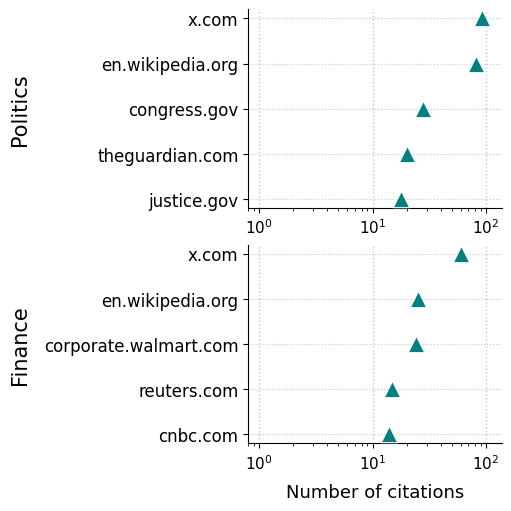

In [6]:
# --- Constants & Setup ---
DOMAINS = ["politics", "finance"]
MODELS = ["Human"]
TARGET_LANG = "en"  # Fixing language to English for the main paper figure

MODEL_URLS = {
    "Human": human_urls
}

MODEL_MARKERS = {
    "Human": "^"
}

MODEL_COLORS = {
    "Human": "#008080",       # Teal
}

def clean_domain(x):
    if not isinstance(x, str) or not x.strip():
        return None
    x = x.strip().lower()
    if x.startswith(("http://", "https://")):
        x = urlparse(x).netloc.lower()
    x = x.split("@")[-1].split(":")[0]
    if x.startswith("www."):
        x = x[4:]
    return x or None

def top_domains_for_setting(model_urls, claim_domain, lang, n=10):
    counts = Counter()
    for claim_id, urls in model_urls.items():
        if claim_id not in df.index:
            continue
        row = df.loc[claim_id]
        if row["domain"] == claim_domain and row["language"] == lang:
            counts.update(
                d for d in (clean_domain(u) for u in urls)
                if d
            )
    return counts.most_common(n)


def plot_main_paper_figure(n=10):
    # 2 Rows (Domains) x 1 Column (Model)
    # Adjusted figsize to e.g. 5x5 so it fits nicely in a single column
    fig, axes = plt.subplots(
        nrows=len(DOMAINS),
        ncols=len(MODELS),
        figsize=(5, 5),  
        constrained_layout=True,
        squeeze=False,  # CRITICAL: Keeps axes as a 2D array so [r, c] indexing still works
    )

    all_max = 1
    all_panels = {}

    # 1. Pre-calculate all data to find the global maximum for a consistent X-axis
    for r, claim_domain in enumerate(DOMAINS):
        for c, model_name in enumerate(MODELS):
            model_urls = MODEL_URLS[model_name]
            top = top_domains_for_setting(model_urls, claim_domain, TARGET_LANG, n=n)
            all_panels[(r, c)] = top
            
            if top:
                all_max = max(all_max, max(v for _, v in top))

    # 2. Plotting loop
    for r, claim_domain in enumerate(DOMAINS):
        for c, model_name in enumerate(MODELS):
            ax = axes[r, c]
            top = all_panels[(r, c)]
            
            # Fetch model-specific styles
            model_color = MODEL_COLORS.get(model_name, "#2ca02c")
            model_marker = MODEL_MARKERS.get(model_name, "D")

            if top:
                labels = [d for d, _ in top][::-1]
                values = [v for _, v in top][::-1]
                y = range(len(labels))

                ax.scatter(
                    values,
                    y,
                    marker=model_marker,
                    c=model_color,
                    edgecolor="white",
                    linewidth=0.8,
                    s=140,
                    zorder=3,
                )

                ax.set_yticks(list(y))
                ax.set_yticklabels(labels, fontsize=12)
            else:
                ax.text(
                    0.5, 0.5, "no citations",
                    ha="center", va="center",
                    transform=ax.transAxes,
                    fontsize=12, color="gray", style='italic'
                )
                ax.set_yticks([])

            # Apply consistent X-axis scale across all subplots
            ax.set_xscale("log")
            ax.set_xlim(0.8, all_max * 1.5)

            # Styling: Grid and Spines
            ax.grid(True, axis="x", which="major", linestyle=":", linewidth=1, zorder=0, alpha=0.7)
            ax.grid(True, axis="y", which="major", linestyle=":", linewidth=0.8, zorder=0, alpha=0.7)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis="x", labelsize=11)

            # --- Labels ---

            # Row Labels (Leftmost column): Domain Names
            if c == 0:
                ax.set_ylabel(claim_domain.capitalize(), fontsize=15, labelpad=10)

            # X-axis Labels (Bottom row)
            if r == len(DOMAINS) - 1:
                ax.set_xlabel("Number of citations", fontsize=13, labelpad=8)

    # Align the Y-labels (Domains) perfectly vertically
    fig.align_ylabels(axes[:, 0])

    fig.savefig("graphs/cf_h_top_domains_en.pdf", bbox_inches="tight")

    plt.show()

# Execute the plot generation
plot_main_paper_figure(n=5)

Plotting for Human...


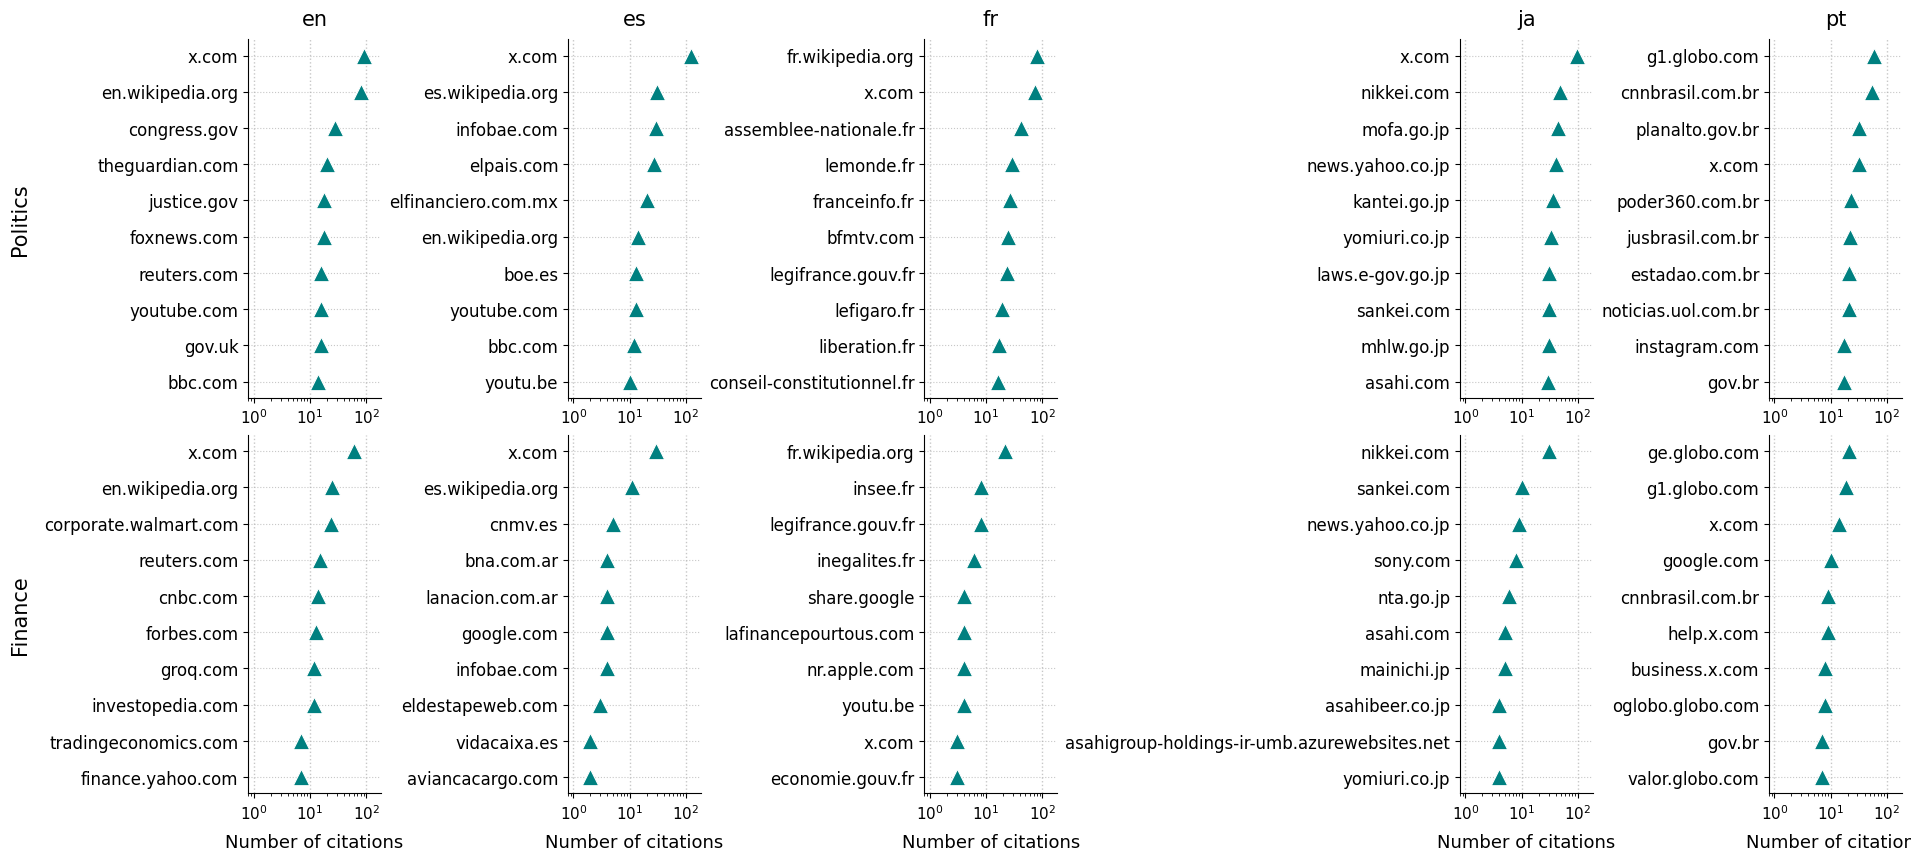

In [7]:
DOMAINS = ["politics", "finance"]
LANGS = ["en", "es", "fr", "ja", "pt"]


def plot_one_model(model_name, model_urls, n=10):
    # 2. INCREASED: Slightly taller figure to accommodate larger fonts
    fig, axes = plt.subplots(
        nrows=len(DOMAINS),
        ncols=len(LANGS),
        figsize=(19, 8.5), 
        constrained_layout=True,
    )

    all_max = 1
    all_panels = {}

    for r, claim_domain in enumerate(DOMAINS):
        for c, lang in enumerate(LANGS):
            top = top_domains_for_setting(model_urls, claim_domain, lang, n=n)
            all_panels[(r, c)] = top

            if top:
                all_max = max(all_max, max(v for _, v in top))

    # Retrieve the specific color for the model being plotted
    model_color = MODEL_COLORS.get(model_name, "#2ca02c")

    for r, claim_domain in enumerate(DOMAINS):
        for c, lang in enumerate(LANGS):
            ax = axes[r, c]
            top = all_panels[(r, c)]

            if top:
                labels = [d for d, _ in top][::-1]
                values = [v for _, v in top][::-1]
                y = range(len(labels))

                # 3. IMPROVED: Larger markers, applied color, added subtle borders, and zorder
                ax.scatter(
                    values,
                    y,
                    marker=MODEL_MARKERS.get(model_name, "D"),
                    c=model_color,
                    edgecolor="white",  # Adds a clean border to the shapes
                    linewidth=0.8,
                    s=140,              # Increased from 55 to 140
                    zorder=3,           # Ensures points draw on top of the grid
                )

                ax.set_yticks(list(y))
                ax.set_yticklabels(labels, fontsize=12) # Increased from 9

            else:
                ax.text(
                    0.5,
                    0.5,
                    "no citations",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                    fontsize=12,
                    color="gray"
                )
                ax.set_yticks([])

            ax.set_xscale("log")
            ax.set_xlim(0.8, all_max * 1.5)

            # 4. CLEANED: Pushed grid behind data, lowered opacity slightly
            ax.grid(True, axis="x", which="major", linestyle=":", linewidth=1, zorder=0, alpha=0.7)
            ax.grid(True, axis="y", which="major", linestyle=":", linewidth=0.8, zorder=0, alpha=0.7)
            
            # Remove top and right box spines for a cleaner aesthetic
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.tick_params(axis="x", labelsize=11) # Increased from 9

            if r == 0:
                ax.set_title(lang, fontsize=15, pad=10) # Increased from 13

            if c == 0:
                ax.set_ylabel(claim_domain.capitalize(), fontsize=15, labelpad=10) # Increased from 13

            if r == len(DOMAINS) - 1:
                ax.set_xlabel("Number of citations", fontsize=13, labelpad=8) # Increased from 11


    # ADD THIS LINE to snap the y-labels ("Politics", "Finance") into perfect vertical alignment
    fig.align_ylabels(axes[:, 0]) 

    fig.savefig(f"graphs/cf_h_top_domains_{model_name}.pdf", bbox_inches="tight")

    plt.show()


for model_name, model_urls in MODEL_URLS.items():
    print(f"Plotting for {model_name}...")
    plot_one_model(
        model_name,
        model_urls,
        n=10,
    )